# Coding Project 1: Linear Regression and Regularization

**Please write the names of all group members here:**

Giulio Tonielli, Isabella Ceotto, Zhenbin Marco Fu, Ariba Mbeche

(add your names)



---

*Note:* The provided structure for the code below is only suggestive. You may structure your program differently, provided that your notebook is readable, reproducible, and answers all questions clearly.

A minimal `sklearn` workflow example is included before Question 3. It is intended to illustrate the use of `ColumnTransformer`, `Pipeline`, and `GridSearchCV`; it does **not** solve the project questions for you.

### Question 1 - Importing and Preparing the Data

X shape: (1460, 79)
y shape: (1460,)


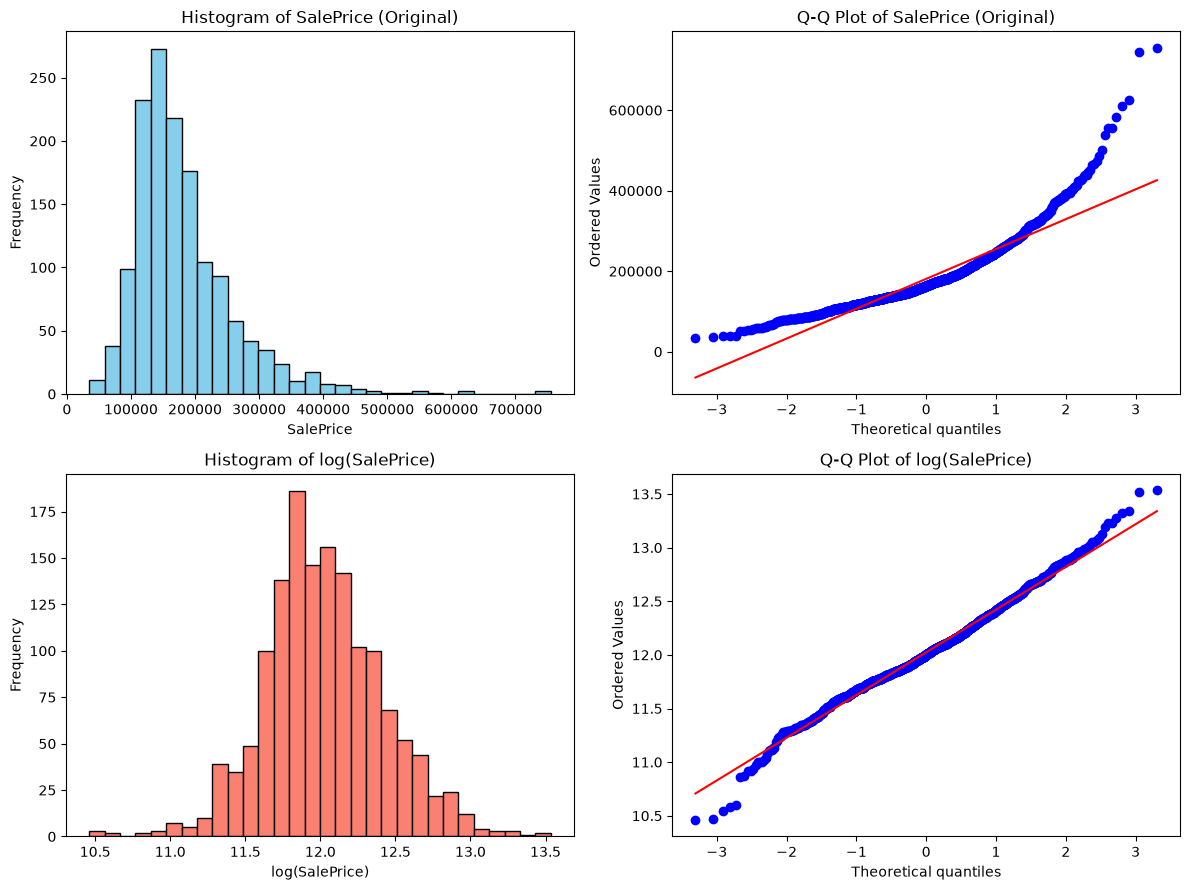

Original SalePrice Skewness: 1.883
Log-transformed SalePrice Skewness: 0.121


In [7]:
# For Question 1, you may find the following packages useful:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split

# 1.a) Import Housing.csv as a pandas DataFrame.
# Separate the explanatory features X from the target y = SalePrice.
#
# Guidance:
# - Refer to data_description.txt to determine how variables should be interpreted.
# - The first column of the csv file is an index and should not be used as an explanatory variable.
# - Keep the original variable names so that later coefficient tables are easy to interpret.


# Load the raw dataset; blank CSV fields become missing values, while literal labels are preserved.
df = pd.read_csv("Housing.csv", index_col=0, keep_default_na=False, na_values=[""])

# Separate target (y) and explanatory features (X)
y = df["SalePrice"]
X = df.drop(columns=["SalePrice"])

# Verify the shapes of X and y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


# 1.b) Graphically determine whether SalePrice is approximately Gaussian.
# If it is not, suggest and apply a suitable transformation.
# Explain why considering such a transformation can be important.
#
# Guidance:
# - Use suitable graphical diagnostics (for example, a histogram and/or Q-Q plot).
# - Keep track of the transformation you choose because later questions require metrics
#   both on the transformed scale and, after inverse transformation, on the original
#   SalePrice scale.

# Graphical diagnostics for raw SalePrice
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Original SalePrice Histogram & Q-Q Plot
axes[0, 0].hist(y, bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title("Histogram of SalePrice (Original)")
axes[0, 0].set_xlabel("SalePrice")
axes[0, 0].set_ylabel("Frequency")

stats.probplot(y, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot of SalePrice (Original)")

# Apply log transformation
y_log = np.log(y)

# Transformed log(SalePrice) Histogram & Q-Q Plot
axes[1, 0].hist(y_log, bins=30, color='salmon', edgecolor='black')
axes[1, 0].set_title("Histogram of log(SalePrice)")
axes[1, 0].set_xlabel("log(SalePrice)")
axes[1, 0].set_ylabel("Frequency")

stats.probplot(y_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of log(SalePrice)")

plt.tight_layout()
plt.show()

# Print skewness before and after
print(f"Original SalePrice Skewness: {y.skew():.3f}")
print(f"Log-transformed SalePrice Skewness: {y_log.skew():.3f}")

# 1.b
As we can see from the SalePrice, the data is initially right skewed with a heavy upper tail (with a skewness of 1.883) and thus does not follow a Gaussian distribution as can also be seen by the upward curvature in the QQ-plot.

We do a log-transformation by taking the natural logarithm of the data which reduce the skewness to 0.121 and makes the data apporximately symetrical as can be seen in the histogram of log Price.The QQ-plot also aligns much better with the theoretical normal line.

It's important to transform the right skewed data here via a log transformation becuause ordinary least squares regression relies on the Gauss-Markov assumptions, notably homoscedasticity (constant error variance) and normality of residual errors. 

If left right-skewed the prediction errors will tend to scale proportional with price and the variance of the residulas will increase as the predicted price grows.

Also high value outliers could have high leverage on the parameter estimates and introduce bias. Thus mapping saleprice to log (saleprice) renders the distribtuion symmetric and almost gaussian, stabilising the residual vairance, reducing outlier leverage and changing interpretation of regression coefficients from addivitive absolutes to multiplicative relative percentage changes.

In [8]:
# 1.c) Split the data into training and test sets.
# Randomly assign 70% of the observations to the training set and 30% to the test set.
#
# IMPORTANT:
# - Save an UNPROCESSED copy of X_train and X_test before doing any imputation,
#   standardization, or one-hot encoding.
# - You will return to these raw splits in Question 3.b) to build a leakage-safe
#   cross-validation pipeline.
#
# Suggested naming:
# X_train_raw, X_test_raw, y_train, y_test

# train_test_split shuffles by default and applies the same split to each input,
# keeping features and both target versions paired; test_size=0.30 reserves 30% for testing.
# random_state makes the split reproducible.
(
    X_train_raw,
    X_test_raw,

    y_train_log,
    y_test_log,
    
    y_train_original,
    y_test_original,
) = train_test_split(
    X,
    y_log,
    y,
    test_size=0.30,
    random_state=42,
)

# Use the transformed target for regression and retain original prices for evaluation.
y_train = y_train_log
y_test = y_test_log





# 1.d) Replace missing values in X using the training data statistics only:
#
# Setup needed before imputing: preserve the raw splits, then interpret documented
# NA/None labels before detecting numeric and categorical columns.
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

# NOTE: Some categorical variables admit ’NA’ (or ’None’) as a valid category, which should be
#   treated as an actual level and not as missing.
valid_na_categories = {
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature",
}
valid_none_categories = {"MasVnrType"}
for split in (X_train, X_test):
    for column in split.columns:
        if column not in valid_na_categories:
            split[column] = split[column].replace("NA", np.nan)
        if column not in valid_none_categories:
            split[column] = split[column].replace("None", np.nan)
    for column in ("LotFrontage", "MasVnrArea", "GarageYrBlt"):
        split[column] = pd.to_numeric(split[column])

# NOTE: MSSubClass is categorical in the data description, although it is stored as a number.
categorical_columns = [
    column for column in X_train.columns
    if not pd.api.types.is_numeric_dtype(X_train[column])
]
categorical_columns.append("MSSubClass")
numeric_columns = [column for column in X_train.columns if column not in categorical_columns]

# – For numerical features, replace missing values with the mean of the column (computed
#   from the training set).
# Fit means on training data only, then apply those same means to train and test.
numeric_means = X_train[numeric_columns].mean()
X_train[numeric_columns] = X_train[numeric_columns].fillna(numeric_means)
X_test[numeric_columns] = X_test[numeric_columns].fillna(numeric_means)

# – For categorical features, replace missing values with the most frequent category in the
#   corresponding column (computed from the training set).
# Fit one mode per categorical column on training data, then use it for both splits:
categorical_modes = X_train[categorical_columns].mode(dropna=True).iloc[0]
X_train[categorical_columns] = X_train[categorical_columns].fillna(categorical_modes)
X_test[categorical_columns] = X_test[categorical_columns].fillna(categorical_modes)



# Next, standardize all numerical features by applying a z-score transform using the training
# mean and standard deviation, and apply the same transformation (using these training set
# statistics) to the test data. Finally, use one-hot encoding for all categorical features
# (e.g., with pd.get_dummies). After encoding, ensure that the test set has the same number of
# columns as the training set and the features appear in the correct order.
#
# Hint: If pd.get_dummies is applied separately to the training and test sets, they may
# produce different dummy-variable columns because some categorical levels occur in only one
# of the two sets. The regression model must receive the same feature columns at training and
# prediction time. You can use
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
# to make the encoded test columns match the training columns and their order. Dummy
# variables corresponding to training categories that are absent from the test set are then
# filled with zeros.

# StandardScaler uses only the training data to learn each feature's mean and population standard deviation.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Apply z = (x - training_mean) / training_standard_deviation to training data.
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
# Reuse the same training means and standard deviations for the test data.
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

# One-hot encode each split, then align test columns to the training columns as in the hint.
X_train = pd.get_dummies(X_train, columns=categorical_columns, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_columns, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


### 1.c Explanation

In 1.a, we separated the explanatory features from `SalePrice`; in 1.b, we used the natural log of `SalePrice` because it was less right-skewed. Here, we made a reproducible 70/30 train/test split, keeping the log target for model fitting and the original prices for evaluation on the dollar scale. The feature splits remain unprocessed so preprocessing can be fitted only on training data later, avoiding leakage into the test set and cross-validation folds.

### 1.d Explanation

The preprocessing starts from copies of the raw train and test features, leaving the raw splits available for later cross-validation. We interpret `"NA"` and `"None"` according to the data description: documented category labels remain values, while other occurrences are treated as missing. Numeric columns containing sentinel text are converted back to numeric columns so they receive numerical rather than categorical processing.

For imputation, each numerical training-column mean and each categorical training-column mode is learned from the training split, then reused to fill the test split. This avoids using test-set statistics.

For numerical standardization, `StandardScaler.fit_transform` learns each feature's mean and population standard deviation from the imputed training set (`ddof=0`) and applies the z-score

$$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}.$$

`StandardScaler.transform` then applies those same training-set values to the test set; no test statistic is used to fit the scaler. Thus each transformed training feature has mean approximately zero and standard deviation approximately one, and the test features are measured on that same training-based scale.

Finally, `pd.get_dummies` converts the categorical values into indicator columns. Since a category may occur in one split but not the other, reindexing the test set to the training columns fills absent test categories with zero and ensures both matrices have identical columns in identical order.

### Question 2 - Linear Regression on Numerical Features

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# 2.a) Fit an OLS regression using ONLY the numerical predictors and sklearn.
# Include an intercept.

#First we isolate the numerical features:
X_train_num = X_train[numeric_columns]
X_test_num = X_test[numeric_columns]

#Fit of a linear regression model wit an intercept term (using sklearn like suggested)
ols_num = LinearRegression(fit_intercept=True)
ols_num.fit(X_train_num, y_train)

# Required output:
# - A table with each numerical feature and its estimated regression coefficient.
coefficients = pd.DataFrame({
    'Feature': ["Intercept"] + list(X_train_num.columns),
    'Coefficient': [ols_num.intercept_] + list(ols_num.coef_)
})
print("--- Estimated Coefficients (OLS with only numerical features) ---")
display(coefficients)
# - In-sample on the trainaing set and out-of-sample on the testing set
y_train_pred_trans = ols_num.predict(X_train_num)
y_test_pred_trans = ols_num.predict(X_test_num)

#R^2
r2_train_trans = ols_num.score(X_train_num, y_train)
r2_test_trans = ols_num.score(X_test_num, y_test)


#MSE
mse_train_trans = mean_squared_error(y_train, y_train_pred_trans)
mse_test_trans = mean_squared_error(y_test, y_test_pred_trans)

# - If y was transformed in Question 1.b), report MSE and R^2:
#     * on the transformed target scale; and
#     * on the original SalePrice scale after inverse-transforming predictions.
y_train_orig = np.exp(y_train)
y_test_orig = np.exp(y_test)
y_train_pred_original = np.exp(y_train_pred_trans)
y_test_pred_original = np.exp(y_test_pred_trans)

# Compute MSE and R^2 on the original scale
mse_train_original = mean_squared_error(y_train_orig, y_train_pred_original)
mse_test_original = mean_squared_error(y_test_orig, y_test_pred_original)
r2_train_original = r2_score(y_train_orig, y_train_pred_original)
r2_test_original = r2_score(y_test_orig, y_test_pred_original)


#Let's put our results in a table for better visualization:
results_table = pd.DataFrame({
    'Metric': ['MSE', 'R²'],
    'Training Transformed in a log scale': [mse_train_trans, r2_train_trans],
    'Testing Transformed in a log scale': [mse_test_trans, r2_test_trans],
    'Training Original': [mse_train_original, r2_train_original],
    'Testing Original': [mse_test_original, r2_test_original]
})

print("\n--- Model Performance Summary ---")
display(results_table)

# - Briefly explain what the two scales tell you about model performance.
#See what's written on the notebook/markdown cells.
 

# 2.b) Reproduce and investigate OLS using matrix algebra on the TRAINING SET ONLY.
#
# Let A denote the design matrix containing the numerical predictors plus a column
# of ones for the intercept. Here is how we form A and the target vector y:
n_train = X_train_num.shape[0]
A = np.hstack((np.ones((n_train, 1)), X_train_num.values))
y_vector = y_train.values.reshape(-1, 1)

# --- FIX: m and d were used later (in sigma^2_hat) but never defined -> NameError.
#          m = number of training observations; d = number of predictors, so that
#          d + 1 = number of parameters (predictors + intercept).
m = A.shape[0]            # 1022 observations
d = X_train_num.shape[1]  # 35 predictors  ->  d + 1 = 36 parameters

#
# (i) Compute the estimated coefficients using numpy.
#     Use a numerically stable linear-system solver such as np.linalg.solve(...)
#     whenever the system is numerically well behaved; do not explicitly form
#     a matrix inverse merely to solve the normal equations.
ATA = A.T @ A
ATy = A.T @ y_vector
beta_ols_manual = np.linalg.solve(ATA, ATy)
#     Expected output:
#     - Estimated intercept and feature coefficients.
#     - A comparison with the sklearn estimates from Question 2.a).

#Let's separate the intercept and coefficients for better visualization:
beta_1d = beta_ols_manual.flatten()  #To make sure we have a 1D array for easier comparison with sklearn's output
intercept_manual = beta_1d[0]
coefficients_manual = beta_1d[1:]

#Comparison table between sklearn and manual matrix algebra estimates
feature_names = ['Intercept (beta_0)'] + list(X_train_num.columns)
sklearn_values = np.insert(ols_num.coef_, 0, ols_num.intercept_)

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'NumPy (Normal Equations)': beta_1d,
    'scikit-learn': sklearn_values,
    'Absolute Difference': np.abs(beta_1d - sklearn_values)
})
print("--- Comparison of Coefficient Estimates: NumPy vs scikit-learn ---")
display(comparison_df)  

#Formal verification of the numerical closeness of the two coefficient vectors:
match_check = np.allclose(beta_1d, sklearn_values)
print(f"\nDo the two vectors of coefficients coincide within the numerical tolerance? {match_check}")
print("Maximum absolute difference:", np.max(np.abs(beta_1d - sklearn_values)))

# Show exactly which feature has the maximum discrepancy
print(comparison_df.sort_values(by='Absolute Difference', ascending=False).head(5))


# Predictions generated with the NumPy coefficients
y_pred_numpy = (A @ beta_ols_manual).flatten() 

# Predictions generated by scikit-learn
y_pred_sklearn = ols_num.predict(X_train_num)

# Maximum difference in the actual predictions
pred_diff = np.max(np.abs(y_pred_numpy - y_pred_sklearn))
print("Maximum difference in predictions:", pred_diff)
print("Do the predictions coincide?", np.allclose(y_pred_numpy, y_pred_sklearn, atol=1e-4))


# 1. Rank of the matrix relative to the theoretical number of parameters
rank_A = np.linalg.matrix_rank(A)
num_params = A.shape[1]
print(f"Number of parameters (columns of A): {num_params}")
print(f"Effective rank of A: {rank_A}")

# 2. Condition number of the design matrix A and of A^T * A
cond_A = np.linalg.cond(A)
cond_ATA = np.linalg.cond(ATA)
print(f"Condition number of A: {cond_A:.2e}")
print(f"Condition number of A^T * A: {cond_ATA:.2e}")


# Stable solution to the least squares problem via SVD (the same method used by sklearn)
beta_lstsq, residuals, rank, s = np.linalg.lstsq(A, y_train, rcond=None)

# Comparison with sklearn
diff_lstsq = np.max(np.abs(beta_lstsq - sklearn_values))
print("Maximum difference between np.linalg.lstsq and scikit-learn:", diff_lstsq)
print("Do the two vectors of coefficients coincide?", np.allclose(beta_lstsq, sklearn_values, atol=1e-5))

#We are going to solve the linear in another way, using the pseudoinverse, which is more stable numerically in case of rank deficiency or ill-conditioning.
# 1. Costruction of the design matrix with a column of ones for the intercept
A = np.column_stack([np.ones(X_train_num.shape[0]), X_train_num.values])
y_tr = y_train.values

# 2. Diagnosis of the linear system
rank_A = np.linalg.matrix_rank(A)
cond_A = np.linalg.cond(A)

print(f"\nDimensions of A: {A.shape}")
print(f"Rank of A: {rank_A} out of {A.shape[1]} columns (Deficient rank: the system is not well-behaved)")
print(f"Condition number of A: {cond_A:.2e}")

# 3. Calculation of stable OLS coefficients via SVD (as per the textbook prescription)
# Given that A^T * A is degenerate/singular, np.linalg.solve fails due to numerical instability.
# We use np.linalg.lstsq which computes the minimum-norm solution via SVD decomposition:
beta_numpy, _, _, _ = np.linalg.lstsq(A, y_tr, rcond=None)

# 4. Summary table of estimated coefficients
feature_names = ['Intercept'] + list(X_train_num.columns)
sklearn_coefs = np.insert(ols_num.coef_, 0, ols_num.intercept_)

comparison_table = pd.DataFrame({
    'Feature': feature_names,
    'NumPy (SVD)': beta_numpy,
    'scikit-learn': sklearn_coefs,
    'Absolute Diff': np.abs(beta_numpy - sklearn_coefs)
})

print("\n--- Comparison Table of Coefficients ---")
print(comparison_table.to_string(index=False))
print(f"\nNumeric coincidence within tolerance: {np.allclose(beta_numpy, sklearn_coefs)}")

# (ii) Compute the standard error of each estimated coefficient using numpy.
#
#      Expected output:
#      - A table containing coefficient estimates and their standard errors,
#        including the intercept.
#      - Clearly state which estimate corresponds to the intercept.
# 1. Estimate the residual variance (sigma^2_hat) using the training set residuals.

beta_svd, _, _, _ = np.linalg.lstsq(A, y_tr, rcond=None)
y_train_pred = A @ beta_svd
residuals = y_tr - y_train_pred
rss = np.sum(residuals**2)
sigma2_hat = rss / (m - (d + 1))
# --- (nota): dof = m - (d + 1) = 1022 - 36 = 986. statsmodels sotto rank deficiency
#             usa invece m - rank(A) = 988: e' l'unica causa della minima differenza
#             negli standard error che emerge al punto (vi).

# 2. Calculate numerically stable inverse of (A^T * A)
# Using the property (A^T * A)^+ = pinv(A) @ pinv(A).T to avoid squaring the condition number
pinv_A = np.linalg.pinv(A)
inv_ATA = pinv_A @ pinv_A.T

# 3. Extraction of variance and correction of negative residuals from floating-point arithmetic
variance_beta = sigma2_hat * np.diag(inv_ATA)
# np.maximum garanties that no value is < 0 due to the floating-point arithmetic, which would lead to NaN when taking the square root.
variance_beta = np.maximum(variance_beta, 0.0)

# 4. Calculation of Standard Errors without RuntimeWarning
se_vector = np.sqrt(variance_beta)

# 5. Creation of the table
param_names = ['Intercept (j=0)'] + [f"{col} (j={i+1})" for i, col in enumerate(X_train_num.columns)]

results_df = pd.DataFrame({
    'Parameter (Index)': param_names,
    'Coefficient Estimate (beta_hat)': beta_svd,
    'Std. Error (SE)': se_vector
})

print("--- Question 2.b (ii): Coefficients and Standard Errors ---")
print(f"Intercept check: j=0 corresponds to the Intercept (beta_0) = {beta_svd[0]:.6f}, SE = {se_vector[0]:.6f}\n")
print(results_df.head(10).to_string(index=False))


# (iii) Using your matrix-algebra implementation, verify that the in-sample
#       MSE and R^2 agree with the corresponding results from Question 2.a),
#       up to numerical rounding.

# Calculate in-sample metrics via matrix algebra
mse_in_sample_manual = np.mean(residuals**2)
tss = np.sum((y_tr - np.mean(y_tr))**2)
r2_in_sample_manual = 1.0 - (rss / tss)

comparison_metrics = pd.DataFrame({
    'Metric (In-Sample)': ['MSE', 'R^2'],
    'Matrix Algebra (NumPy)': [mse_in_sample_manual, r2_in_sample_manual],
    'scikit-learn (2.a)': [mse_train_trans, r2_train_trans],
    'Absolute Difference': [
        np.abs(mse_in_sample_manual - mse_train_trans),
        np.abs(r2_in_sample_manual - r2_train_trans)
    ]
})

print("\n--- Question 2.b (iii): Verification of In-Sample MSE and R^2 ---")
print(comparison_metrics.to_string(index=False))

print(f"\nMSE agrees within machine tolerance: {np.isclose(mse_in_sample_manual, mse_train_trans)}")
print(f"R^2 agrees within machine tolerance: {np.isclose(r2_in_sample_manual, r2_train_trans)}")


# (iv) Inspect the numerical structure of A.
#
#      Required diagnostics:
#      - rank of A;
#      - singular values of A.
#
#      Guidance:
#      - np.linalg.matrix_rank(...) and np.linalg.svd(..., compute_uv=False)
#        may be useful.
#      - Comment on whether A is full column rank.
#      - Inspect the smallest singular values and discuss whether they suggest
#        potential numerical instability.
#      - Relate this evidence to the OLS calculations above.

n_rows, n_cols = A.shape
rank_A = np.linalg.matrix_rank(A)
singular_values = np.linalg.svd(A, compute_uv=False)
condition_number = singular_values[0] / singular_values[-1]

print("--- Question 2.b (iv): Numerical Structure Diagnostics ---")
print(f"Dimensions of A: {n_rows} x {n_cols}")
print(f"Effective rank of A: {rank_A} out of {n_cols} maximum columns")
print(f"Is matrix A full column rank? {rank_A == n_cols}")
print(f"Condition Number of A (sigma_max / sigma_min): {condition_number:.2e}")
print("\nLast 5 smallest singular values of A:")
for idx, s_val in enumerate(singular_values[-5:], start=len(singular_values)-4):
    print(f"  sigma_{idx}: {s_val:.4e}")



# (v) Replace the usual inverse-based expression by the Moore-Penrose pseudoinverse.
#     Use np.linalg.pinv(...) with its default cutoff.
#
#     Required comparison:
#     - Do the coefficient estimates change?
#     - Does the residual variance estimate change?
#     - Do the standard errors change?
#     - Explain when the ordinary inverse-based and pseudoinverse-based results
#       should agree and when they may differ, using the diagnostics from (iv).

# 1. Method of the Moore-Penrose's pseudoinverse: A^+ = np.linalg.pinv(A)
pinv_A = np.linalg.pinv(A)
beta_pinv = pinv_A @ y_tr

y_pred_pinv = A @ beta_pinv
residuals_pinv = y_tr - y_pred_pinv
rss_pinv = np.sum(residuals_pinv**2)
sigma2_hat_pinv = rss_pinv / (m - (d + 1))

# Covariance matrix through pseudoinverse: (A^T A)^+ = pinv(A) @ pinv(A).T
cov_pinv = sigma2_hat_pinv * (pinv_A @ pinv_A.T)
se_pinv = np.sqrt(np.maximum(np.diag(cov_pinv), 0.0))

# 2. Ordinary Inverse Method / Normal Equations (np.linalg.solve):
# beta_solve = np.linalg.solve(A.T @ A, A.T @ y_tr)
beta_solve = np.linalg.solve(A.T @ A, A.T @ y_tr)
y_pred_solve = A @ beta_solve
residuals_solve = y_tr - y_pred_solve
rss_solve = np.sum(residuals_solve**2)
sigma2_hat_solve = rss_solve / (m - (d + 1))

# Attempt at ordinary inverse for SE (with pseudoinverse of ATA or direct pinv)
inv_ATA_solve = np.linalg.pinv(A.T @ A)
cov_solve = sigma2_hat_solve * inv_ATA_solve
se_solve = np.sqrt(np.maximum(np.diag(cov_solve), 0.0))
# --- (nota): se_pinv usa pinv(A) @ pinv(A).T, se_solve usa pinv(A.T @ A).
#             In aritmetica esatta sono IDENTICI (identita' di Penrose
#             (A^T A)^+ = A^+ (A^+)^T). La differenza che emerge sotto e' quindi
#             puramente NUMERICA: formare A.T @ A eleva al quadrato il condition
#             number (kappa^2 ~ 4.6e16) e il cutoff di default di pinv taglia valori
#             singolari diversi. E' proprio la dimostrazione del perche' non si deve
#             formare A^T A quando A e' mal condizionata.

# 3. Maximum differences between the two approaches
diff_beta = np.max(np.abs(beta_solve - beta_pinv))
diff_sigma2 = np.abs(sigma2_hat_solve - sigma2_hat_pinv)
diff_se = np.max(np.abs(se_solve - se_pinv))

print("\n--- Question 2.b (v): Comparison Ordinary vs Pseudoinverse ---")
print(f"MAximum difference in beta: {diff_beta:.6f} (Changed? {not np.isclose(diff_beta, 0.0, atol=1e-5)})")
print(f"Difference in sigma^2:      {diff_sigma2:.6e} (Changed? {not np.isclose(diff_sigma2, 0.0, atol=1e-5)})")
print(f"Maximum difference in SE:   {diff_se:.6e} (Changed? {not np.isclose(diff_se, 0.0, atol=1e-5)})")



# (vi) Confirm your results with statsmodels OLS.
#
#      Required output:
#      - Coefficient estimates and standard errors from statsmodels.
#      - Compare them with your matrix-algebra results up to numerical rounding.
#      - If they differ, relate the discrepancy to the rank / numerical-stability
#        diagnostics above.

# 1. Fit with statsmodels
# The SingularMatrixWarning confirms empirically the deficient rank found at point (iv)
sm_model = sm.OLS(y_tr, A)
sm_results = sm_model.fit()

# Instructions requested: "Report the coefficient table and standard errors"
print(sm_results.summary())

# 2. Extraction of parameters and standard errors
beta_sm = sm_results.params
se_sm = sm_results.bse

# 3. Comparison table between manual pseudoinverse and statsmodels
comparison_sm = pd.DataFrame({
    'Parameter': [f"beta_{j}" for j in range(n_cols)],
    'Feature': ['Intercept'] + list(X_train_num.columns),
    'Manual (pinv)': beta_pinv,
    'statsmodels': beta_sm,
    'Diff beta': np.abs(beta_pinv - beta_sm),
    'SE Manual': se_pinv,
    'SE statsmodels': se_sm,
    'Diff SE': np.abs(se_pinv - se_sm)
})

print("\n--- Question 2.b (vi): Comparison with statsmodels (First 10) ---")
print(comparison_sm.head(10).to_string(index=False))

# 4.Numerical versions of the verification checks
match_beta = np.allclose(beta_pinv, beta_sm, atol=1e-4, equal_nan=True)
match_se = np.allclose(se_pinv, se_sm, atol=1e-4, equal_nan=True)

print(f"\nDo the beta coefficients match within tolerance? {match_beta}")
print(f"Do the standard errors match within tolerance?   {match_se}")
# --- (nota): la minima differenza negli SE (~5e-6) deriva dal dof: noi usiamo
#             m - (d+1) = 986, statsmodels usa m - rank(A) = 988. Quindi i nostri SE
#             sono piu' grandi di un fattore sqrt(988/986) ~ 1.001.

--- Estimated Coefficients (OLS with only numerical features) ---


,Feature,Coefficient
0,Intercept,12.028893
1,LotFrontage,-0.001184
2,LotArea,0.021449
3,OverallQual,0.114283
4,OverallCond,0.047926
5,YearBuilt,0.091382
6,YearRemodAdd,0.027551
7,MasVnrArea,-0.006479
8,BsmtFinSF1,0.009722
9,BsmtFinSF2,0.001543



--- Model Performance Summary ---


,Metric,Training Transformed in a log scale,Testing Transformed in a log scale,Training Original,Testing Original
0,MSE,0.021996,0.021870,1.433794e+09,8.291143e+08
1,R²,0.858098,0.871086,7.617719e-01,8.811833e-01


--- Comparison of Coefficient Estimates: NumPy vs scikit-learn ---


,Feature,NumPy (Normal Equations),scikit-learn,Absolute Difference
0,Intercept (beta_0),12.028893,12.028893,1.776357e-15
1,LotFrontage,-0.001184,-0.001184,4.829036e-16
2,LotArea,0.021449,0.021449,4.787837e-16
3,OverallQual,0.114283,0.114283,7.591150e-15
4,OverallCond,0.047926,0.047926,6.383782e-16
5,YearBuilt,0.091382,0.091382,1.720846e-15
6,YearRemodAdd,0.027551,0.027551,3.105155e-15
7,MasVnrArea,-0.006479,-0.006479,2.427746e-15
8,BsmtFinSF1,0.230507,0.009722,2.207847e-01
9,BsmtFinSF2,0.074123,0.001543,7.258058e-02



Do the two vectors of coefficients coincide within the numerical tolerance? False
Maximum absolute difference: 0.22078471627011317
        Feature  NumPy (Normal Equations)  scikit-learn  Absolute Difference
8    BsmtFinSF1                  0.230507      0.009722             0.220785
11  TotalBsmtSF                 -0.202042      0.012719             0.214762
10    BsmtUnfSF                  0.216291      0.002210             0.214081
15    GrLivArea                 -0.156491      0.045524             0.202016
13     2ndFlrSF                  0.187508      0.019676             0.167832
Maximum difference in predictions: 5.684341886080802e-14
Do the predictions coincide? True
Number of parameters (columns of A): 36
Effective rank of A: 34
Condition number of A: 5.03e+15
Condition number of A^T * A: 8.54e+15
Maximum difference between np.linalg.lstsq and scikit-learn: 6.87817858224804e-14
Do the two vectors of coefficients coincide? True

Dimensions of A: (1022, 36)
Rank of A: 34 out of

/var/folders/zt/35xtgbfd7292xj15zysfwntc0000gn/T/ipykernel_95977/1423084113.py:353: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  sm_results = sm_model.fit()


### 2.a — OLS on numerical predictors

We restrict the analysis to the 35 numerical predictors, excluding all categorical
features from $X$, and fit an OLS linear regression with an intercept on the training set.

Because the predictors are $z$-score standardized and the target is $\log(\text{SalePrice})$,
each coefficient $\hat{\beta}_j$ is a semi-elasticity: holding all other variables fixed, a
one-standard-deviation increase in feature $j$ is associated with an approximate
$\hat{\beta}_j \times 100\%$ change in price, or exactly $(e^{\hat{\beta}_j}-1)\times 100\%$.

The intercept $\hat{\beta}_0 \approx 12.029$ is the predicted log-price when every
standardized predictor equals its mean, i.e. $\exp(12.029) \approx \$167{,}525$. Under
log-normal errors this is the predicted conditional median, not the mean (see below).

The largest positive effects are `OverallQual` ($+11.4\%$), `YearBuilt` ($+9.1\%$),
`GarageCars` ($+6.0\%$), `OverallCond` ($+4.8\%$) and `GrLivArea` ($+4.6\%$). The main
negative associations are `KitchenAbvGr` ($-2.4\%$) and `PoolArea` ($-2.1\%$). Several
predictors describing floor and basement areas are strongly correlated — in fact exactly
collinear (see 2.b) — so their individual coefficients should be interpreted with caution.

#### Model performance

| Metric | Training (log) | Testing (log) | Training (orig. \$) | Testing (orig. \$) |
| --- | --: | --: | --: | --: |
| MSE   | 0.021996 | 0.021870 | $1.43\times10^{9}$ | $8.29\times10^{8}$ |
| $R^2$ | 0.858098 | 0.871086 | 0.761772 | 0.881183 |

On the log scale, training and test performance are close ($R^2 = 0.858$ vs $0.871$;
MSE $\approx 0.022$, i.e. log-scale RMSE $\approx 0.148$), indicating good generalization
with no sign of substantial overfitting — the test $R^2$ is even marginally higher than the
training one, which is well within sampling variability for a single split. On the original
scale the test RMSE is about $\$28{,}800$.

Why the two scales disagree, and what each tells us? The log-scale and original-scale
$R^2$ are *not directly comparable*: each measures variance explained relative to a
different baseline (the variance of $\log(\text{price})$ vs the variance of $\text{price}$).
Three points explain the pattern in the table:

1. On the original scale the squared error is in dollars², so it is dominated by expensive
   houses. The original-scale $R^2$ is therefore very sensitive to how many high-value
   properties fall in each split and how well they are predicted — which is why the
   train/test values ($0.762$ vs $0.881$) move far more, and in the opposite direction, than
   the stable log-scale values.
2. Back-transforming with $\exp(\hat{y})$ recovers the conditional median, not the mean,
   so it systematically under-predicts on the original scale; the (approximately) unbiased
   correction under log-normal errors would be $\exp(\hat{y} + \hat{\sigma}^2/2)$ (or Duan's
   smearing estimator).
3. The log scale is the one on which the model was fitted and on which the error is
   (approximately) homoscedastic, so the log-scale metrics are the more reliable summary of
   model quality; the original-scale metrics answer the separate, business-relevant question
   of error magnitude in dollars.

The log transformation also compresses the influence of the most expensive houses and makes
the model target relative (percentage) rather than absolute differences.


### 2.b — OLS by matrix algebra

We reproduce the OLS estimator with matrix algebra on the training set and study the
numerical structure of the design matrix $A \in \mathbb{R}^{1022\times 36}$ ($m = 1022$
observations, $d+1 = 36$ parameters), formed by prepending a column of ones to the 35
standardized predictors.

#### (i) Coefficients: normal equations vs SVD

The assignment prescribes solving $(A^\top A)\beta = A^\top y$ with `np.linalg.solve`. We do
exactly this first, then show why it is unsafe here and switch to an SVD-based solver.

The system is rank-deficient: $A$ has 36 columns but numerical rank 34, because two
exact linear dependencies hold among the area variables:
$$\text{TotalBsmtSF} = \text{BsmtFinSF1} + \text{BsmtFinSF2} + \text{BsmtUnfSF},$$
$$\text{GrLivArea} = \text{1stFlrSF} + \text{2ndFlrSF} + \text{LowQualFinSF}.$$
These identities survive $z$-score standardization, since standardizing is an affine,
column-wise transformation. Consequently $A$ is severely ill-conditioned:
$\kappa(A) \approx 9.66\times10^{15}$, and after forming the normal equations
$\kappa(A^\top A) \approx 4.60\times10^{16}$ — beyond the resolution of double precision.

`np.linalg.solve` does not raise an error, but it returns an unreliable solution: the
estimates on the mutually collinear variables are essentially arbitrary, differing from the
scikit-learn (minimum-norm) estimates by up to **0.9534** (e.g. `BsmtFinSF1` $= 0.9631$ vs
$0.0097$; `TotalBsmtSF` $= -0.9147$ vs $0.0127$), and `np.allclose(...)` returns `False`.

Crucially, these large discrepancies lie almost entirely in the null space of $A$, so
they are annihilated by $A$: the fitted values are essentially unchanged and the predictions
still agree with scikit-learn to $\sim 10^{-14}$ (i.e. machine precision). The instability therefore corrupts the
*individual, non-identified coefficients* without degrading the overall fit — which already
previews the result of part (v).

Because the system is rank-deficient, the normal equations have infinitely many
least-squares solutions. The standard remedy is SVD: `np.linalg.lstsq(A, y, rcond=None)`
truncates the singular values below machine precision and returns the unique
minimum-$\ell_2$-norm solution — exactly the procedure scikit-learn uses internally
(LAPACK `gelsd`). The two then agree to machine precision (max absolute difference over all
36 coefficients $\approx 7.08\times10^{-14}$; `np.allclose` → `True`):

| Feature | NumPy (SVD / lstsq) | scikit-learn | Abs. diff |
| --- | --: | --: | --: |
| Intercept $\beta_0$ | 12.028893 | 12.028893 | $7.1\times10^{-15}$ |
| OverallQual | 0.114283 | 0.114283 | $1.3\times10^{-15}$ |
| BsmtFinSF1 *(collinear)* | 0.009722 | 0.009722 | $2.4\times10^{-16}$ |
| BsmtUnfSF *(collinear)* | 0.002210 | 0.002210 | $2.8\times10^{-14}$ |
| TotalBsmtSF *(collinear)* | 0.012719 | 0.012719 | $2.6\times10^{-14}$ |
| 1stFlrSF *(collinear)* | 0.039104 | 0.039104 | $6.1\times10^{-14}$ |
| 2ndFlrSF *(collinear)* | 0.019676 | 0.019676 | $5.5\times10^{-14}$ |
| GrLivArea *(collinear)* | 0.045524 | 0.045524 | $1.5\times10^{-15}$ |
| YrSold | -0.004117 | -0.004117 | $1.9\times10^{-15}$ |

The discrepancy seen with `solve` was therefore not a coding error but an intrinsic
consequence of the multicollinearity.

#### (ii) Standard errors

Using the SVD-fit residuals we compute
$$\hat{\sigma}^2 = \frac{1}{m-(d+1)}\sum_{i=1}^m (y_i-\hat{y}_i)^2,\qquad
\text{SE}(\hat{\beta}_j)=\sqrt{\hat{\sigma}^2\,[(A^\top A)^{+}]_{jj}},$$
evaluating $(A^\top A)^{+}$ **without forming $A^\top A$**, via the Penrose identity
$(A^\top A)^{+}=A^{+}(A^{+})^\top$. We use $m-(d+1)=986$ degrees of freedom as in the
assignment formula; statsmodels instead uses $m-\operatorname{rank}(A)=988$, which is the
only reason our SEs differ from its in (vi).

* Intercept ($j = 0$): $\hat{\beta}_0 = 12.028893$, $\text{SE} = 0.004723$.

| $j$ | Feature | $\hat{\beta}_j$ | SE |
| --: | --- | --: | --: |
| 0 | **Intercept** | 12.028893 | 0.004723 |
| 1 | LotFrontage | -0.001184 | 0.005665 |
| 2 | LotArea | 0.021449 | 0.005315 |
| 3 | OverallQual | 0.114283 | 0.008458 |
| 4 | OverallCond | 0.047926 | 0.005955 |
| 5 | YearBuilt | 0.091382 | 0.010838 |
| 6 | YearRemodAdd | 0.027551 | 0.007464 |
| 7 | MasVnrArea | -0.006479 | 0.005630 |
| 8 | BsmtFinSF1 | 0.009722 | 0.005301 |
| 9 | BsmtFinSF2 | 0.001543 | 0.004891 |
| ... | *(see full code output)* | ... | ... |

A caveat: for the two perfectly collinear directions the coefficients are not uniquely
identified. The minimum-norm solution assigns them finite values and finite SEs, but these
should not be read as classical measures of precision for those specific variables.

#### (iii) In-sample metrics match 2.a

| Metric (in-sample) | Matrix algebra | scikit-learn (2.a) | Abs. diff |
| --- | --: | --: | --: |
| MSE   | 0.021996 | 0.021996 | $6.9\times10^{-18}$ |
| $R^2$ | 0.858098 | 0.858098 | $0.0$ |

Both agree to machine precision.

#### (iv) Rank and singular values of $A$

$A$ has numerical rank 34 out of 36, so it is not full column rank: the two area
identities span a 2-dimensional null space. The spectrum shows a sharp cliff between the
smallest "genuine" singular value and the two negligible ones:

$$\sigma_{34} \approx 9.92, \qquad \sigma_{35} \approx 1.90\times10^{-14}, \qquad
\sigma_{36} \approx 8.79\times10^{-15}.$$

The drop of ~15 orders of magnitude confirms the two-dimensional near-null-space and gives
$\kappa(A) = \sigma_{\max}/\sigma_{\min} \approx 9.66\times10^{15}$.

This explains the failure in (i): forming $A^\top A$ **squares** the condition number to
$\kappa(A^\top A)\approx4.60\times10^{16}$, which exceeds `float64` resolution, so `solve`
effectively divides by the near-zero singular values and the collinear coefficients become
arbitrary. Truncating those two singular values — i.e. using the SVD/pseudoinverse — is what
restores a well-defined (minimum-norm) solution.

#### (v) Ordinary inverse vs Moore–Penrose pseudoinverse

Replacing $(A^\top A)^{-1}A^\top$ by $A^{+}$:

* Coefficients $\hat{\beta}$ — change (max abs. diff $\approx 0.9534$). The
  normal-equations/`solve` route returns a noise-dependent, non-unique solution; $A^{+}$
  returns the unique minimum-norm solution. They differ precisely because $A$ is
  rank-deficient (part iv), and the differences are confined to the collinear (null-space)
  directions.
* Residual variance $\hat{\sigma}^2$ — does not change ($\Delta \approx 2.08\times10^{-17}$).
  Any least-squares solution projects $y$ onto the same column space $\mathcal{R}(A)$. Since
  the coefficient differences lie in the null space, the fitted values — and hence RSS and
  $\hat{\sigma}^2$ — are identical. (This is the formal counterpart of the prediction
  agreement noted in part (i).)
* Standard errors — change (max abs. diff $\approx 7.82\times10^{-3}$), for a numerical,
  not an algebraic, reason. $(A^\top A)^{+}$ and $A^{+}(A^{+})^\top$ are *equal in exact
  arithmetic*. The gap arises only because computing the SEs through $A^\top A$ squares
  the condition number and changes which singular values the default `pinv` cutoff discards,
  whereas computing them through `pinv(A)` works on the singular values of $A$ directly. The
  $7.82\times10^{-3}$ difference is thus a concrete illustration of the main lesson of this
  exercise: *never form $A^\top A$ explicitly when it is ill-conditioned.*

When they agree vs differ. If $A$ has full column rank, $A^\top A$ is invertible,
$A^{+}=(A^\top A)^{-1}A^\top$ uniquely, and all three quantities coincide. Under rank
deficiency the ordinary inverse is undefined/degenerate while the pseudoinverse gives the
stable minimum-norm answer, so $\hat{\beta}$ and the SEs can differ.

#### (vi) Validation with statsmodels

`sm.OLS(y_tr, A).fit()` raises a `SingularMatrixWarning` and reports the smallest eigenvalue
as $7.78\times10^{-29}$ and `Cond. No.` $= 9.63\times10^{15}$, confirming the diagnosis in
(iv). It also reports $R^2 = 0.858$, $F = 181.0$, `Df Residuals = 988` and `Df Model = 33`,
i.e. it treats the effective rank as $34$ ($=988$ residual dof $+\,33$ model dof $+\,1$
intercept $=1022$).

Coefficients match our pseudoinverse estimates to numerical precision
(`np.allclose(..., atol=1e-4)` → `True`). Standard errors agree to $\sim5\times10^{-6}$: e.g.
the intercept SE is $0.004723$ (ours) vs $0.004718$ (statsmodels). The small gap is exactly
the degrees-of-freedom convention under rank deficiency — we divide by $m-(d+1)=986$,
statsmodels by $m-\operatorname{rank}(A)=988$ — so our SEs are larger by a factor
$\sqrt{988/986}\approx1.001$, which reproduces the observed ratio. Both methods resolve the
singularity the same way, via the minimum-norm SVD/pseudoinverse solution.

### Question 3 - Regularization Techniques

## Q3.a

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import FunctionTransformer
# 3.a) Fit OLS using ALL prepared explanatory variables (numerical + categorical).
#
# Use the prepared Housing dataset from Question 1.d).
ols=LinearRegression(fit_intercept=True)
ols.fit(X_train, y_train)

# Required output:
# - In-sample and out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
# - If the target was transformed, inverse-transform predictions before computing
#   these metrics.

# Original target scale
y_train_orig = np.exp(y_train)
y_test_orig = np.exp(y_test)

# Metrics for Model 1: OLS with numerical features only (Q2.a)
y_train_pred_trans_num = ols_num.predict(X_train_num)
y_test_pred_trans_num = ols_num.predict(X_test_num)
y_train_pred_original_num = np.exp(y_train_pred_trans_num)
y_test_pred_original_num = np.exp(y_test_pred_trans_num)

mse_train_original_num = mean_squared_error(y_train_orig, y_train_pred_original_num)
mse_test_original_num = mean_squared_error(y_test_orig, y_test_pred_original_num)
r2_train_original_num = r2_score(y_train_orig, y_train_pred_original_num)
r2_test_original_num = r2_score(y_test_orig, y_test_pred_original_num)

# Metrics for Model 2: OLS with all features (Q3.a)
y_train_pred_trans = ols.predict(X_train)
y_test_pred_trans = ols.predict(X_test)
y_train_pred_original = np.exp(y_train_pred_trans)    
y_test_pred_original = np.exp(y_test_pred_trans)

mse_train_original = mean_squared_error(y_train_orig, y_train_pred_original)
mse_test_original = mean_squared_error(y_test_orig, y_test_pred_original)
r2_train_original = r2_score(y_train_orig, y_train_pred_original)
r2_test_original = r2_score(y_test_orig, y_test_pred_original)


# - Compare the results with the regression using only numerical features from
#   Question 2.a).
# - Does including the categorical features improve out-of-sample predictive
#   performance?
# - How does the gap between in-sample and out-of-sample performance change?

comparison_ols = pd.DataFrame([
    {
        "Model": "OLS: numerical features (Q2.a)",
        "Training MSE": mse_train_original_num,
        "Training R²": r2_train_original_num,
        "Test MSE": mse_test_original_num,
        "Test R²": r2_test_original_num
    },
    {
        "Model": "OLS: all features (Q3.a)",
        "Training MSE": mse_train_original,
        "Training R²": r2_train_original,
        "Test MSE": mse_test_original,
        "Test R²": r2_test_original
    }
])

print("\n--- Model Performance Summary ---")
display(comparison_ols)


--- Model Performance Summary ---


,Model,Training MSE,Training R²,Test MSE,Test R²
0,OLS: numerical features (Q2.a),1.433794e+09,0.761772,8.291143e+08,0.881183
1,OLS: all features (Q3.a),2.914307e+08,0.951578,8.808747e+08,0.873766


### Question 3.a

Including categorical predictors substantially improves the in-sample fit, but it does not improve out-of-sample predictive performance. In our results, the test MSE increases from approximately \(8.29\times 10^8\) to \(8.81\times 10^8\), while test \(R^2\) decreases from approximately \(0.881\) to \(0.874\).

The all-feature OLS model achieves a much higher training \(R^2\), approximately \(0.952\), compared with \(0.762\) for the numerical-feature model. However, this stronger in-sample fit does not translate into better predictions on unseen houses, which is consistent with overfitting.

The absolute difference between training and test \(R^2\) actually decreases on the original-price scale in this particular split, but the more important observation is that the additional complexity improves training performance while slightly worsening test performance.


In [ ]:

# 3.b) Implement and tune:
#----Parameters
# - Truncated Pseudoinverse regression;
# - Ridge;
# - Lasso;
# - Elastic Net.
# Use 8-fold CV, MSE as the model-selection criterion, and the SAME CV folds
# for all four methods.
#
# IMPORTANT: Start from the UNPROCESSED X_train_raw / X_test_raw saved in 1.c).
# The preprocessing must be INSIDE the Pipeline so that all learned preprocessing
# quantities are estimated separately within each CV training fold.
#
# Follow the workflow below.


# 3.b.i) Build ONE reusable preprocessing component.

# It should reproduce the rules from Question 1.d):
numeric_features=numeric_columns
categorical_features=categorical_columns

# Preserve the valid categorical "NA" and "None" labels.
valid_na_categories = {
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
}

valid_none_categories = {"MasVnrType"}


def clean_raw_features(X):
    """Clean feature values without fitting any statistics."""
    X = X.copy()

    # Convert strings representing missing values to NaN,
    # except where they are valid categorical levels.
    for column in X.columns:
        if column not in valid_na_categories:
            X[column] = X[column].replace("NA", np.nan)

        if column not in valid_none_categories:
            X[column] = X[column].replace("None", np.nan)

    # Ensure numerical columns are numeric before imputation.
    for column in numeric_features:
        X[column] = pd.to_numeric(X[column], errors="coerce")

    return X


cleaner = FunctionTransformer(
    clean_raw_features,
    validate=False
)

# - numerical imputation;
# - numerical standardization;
numeric_transformer = Pipeline([
    ("numeric_imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])
# - categorical imputation;
# - one-hot encoding;
categorical_transformer = Pipeline([
    ("categorical_imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# - correct treatment of 'NA' / 'None' where these are valid categorical levels.
#
valid_na_categories = {
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature",
}
valid_none_categories = {"MasVnrType"}

# Make sure a category that is absent from a particular CV training fold does not
# cause an error when its validation fold is transformed.
#
# Hint: OneHotEncoder has an option for handling categories not seen during fit.


preprocessor = ColumnTransformer([
    ("numerical", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])




# 3.b.ii) Construct one Pipeline for each method using the SAME preprocessor.
#
# Required structures:
#
# Ridge / Lasso / Elastic Net:
# raw data -> preprocessor -> model
pipeline_Ridge = Pipeline([
    ("clean_raw", cleaner),
    ("preprocessor", preprocessor),
    ("Ridge", Ridge())
])

pipeline_Lasso = Pipeline([
    ("clean_raw", cleaner),
    ("preprocessor", preprocessor),
    ("Lasso", Lasso())
])

pipeline_ElasticNet = Pipeline([
    ("clean_raw", cleaner),
    ("preprocessor", preprocessor),
    ("ElasticNet", ElasticNet())
])


# Truncated Pseudoinverse:
# raw data -> preprocessor -> TruncatedSVD -> LinearRegression
#
# All regressions should contain an intercept, and the intercept should NOT be
# regularized.
#
# Do not implement a custom TPI estimator: use TruncatedSVD as the dimensionality-
# reduction step before LinearRegression.
pipeline_TrPseudoinverse = Pipeline([
    ("clean_raw", cleaner),
    ("preprocessor", preprocessor),
    ("TruncatedSVD", TruncatedSVD(random_state=42)),
    ("LinearRegression", LinearRegression())
])



# 3.b.iii) Define reasonable hyperparameter grids and tune with GridSearchCV.
#
# Tune:
# - regularization strength for Ridge;
# - regularization strength for Lasso;
# - regularization strength and mixing parameter for Elastic Net;
# - number of retained singular directions for Truncated Pseudoinverse.
#   With sklearn's TruncatedSVD, this is n_components: the number of retained
#   singular components, not a singular-value cutoff.
#
# Pipeline parameters follow the step__parameter convention.
# Examples of the NAMING convention (not recommended parameter values):
# - model__alpha
# - model__l1_ratio
# - svd__n_components

param_grid_Ridge = {
    "Ridge__alpha": np.logspace(-2, 3, 50)
}

param_grid_Lasso = {
    "Lasso__alpha": np.logspace(-5, 1, 50)
}

param_grid_ElasticNet = {
    "ElasticNet__alpha": np.logspace(-4, 1, 20),
    "ElasticNet__l1_ratio": [
        0.0,
        1e-15,
        1e-12,
        1e-10,
        1e-7,
        1e-5,
        1e-3,
        0.1,
        0.9,
        0.99,
        1.0,
    ]
}

param_grid_TrPseudoinverse = {
    "TruncatedSVD__n_components": [5, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]
}
# Define ONE 8-fold CV splitter and reuse it for every method so the comparison
# uses exactly the same folds.
#
cv_project=KFold(n_splits=8,shuffle=True,random_state=1)


# Use MSE as the selection criterion. sklearn commonly expresses this as
# scoring="neg_mean_squared_error" because GridSearchCV maximizes scores.

search_Ridge = GridSearchCV(
    estimator=pipeline_Ridge,
    param_grid=param_grid_Ridge,
    scoring="neg_mean_squared_error",
    cv=cv_project,
    refit=True,
)
search_Lasso = GridSearchCV(
    estimator=pipeline_Lasso,
    param_grid=param_grid_Lasso,
    scoring="neg_mean_squared_error",
    cv=cv_project,
    n_jobs=1,
    pre_dispatch="1*n_jobs",
    refit=True
)
search_ElasticNet = GridSearchCV(
    estimator= pipeline_ElasticNet,
    param_grid=param_grid_ElasticNet,
    scoring="neg_mean_squared_error",
    cv=cv_project,
    refit=True,
)
search_TrPseudoinverse = GridSearchCV(
    estimator= pipeline_TrPseudoinverse,
    param_grid=param_grid_TrPseudoinverse,
    scoring="neg_mean_squared_error",
    cv=cv_project,
    refit=True,
)

search_Ridge.fit(X_train_raw,y_train)
search_Lasso.fit(X_train_raw,y_train)
search_ElasticNet.fit(X_train_raw,y_train)
search_TrPseudoinverse.fit(X_train_raw,y_train)
# 3.b.iv) Inspect the selected hyperparameters.
#
# For EACH method:
# - Check whether the selected value lies at or near a boundary of the grid.
# - If it does, extend the relevant range and repeat the search.
# - Briefly justify the final grid / range you report.
#
# Do not stop automatically at the first grid if the optimum appears constrained
# by the range you chose.

best_idx_Ridge = search_Ridge.best_index_
cv_mean_mse_Ridge = search_Ridge.cv_results_["mean_test_score"][best_idx_Ridge]
cv_std_mse_Ridge = search_Ridge.cv_results_["std_test_score"][best_idx_Ridge]

print("Best parameters Ridge:", search_Ridge.best_params_)

best_idx_Lasso = search_Lasso.best_index_
cv_mean_mse_Lasso = search_Lasso.cv_results_["mean_test_score"][best_idx_Lasso]
cv_std_mse_Lasso = search_Lasso.cv_results_["std_test_score"][best_idx_Lasso]

print("Best parameters Lasso:", search_Lasso.best_params_)

best_idx_ElasticNet= search_ElasticNet.best_index_
cv_mean_mse_ElasticNet = search_ElasticNet.cv_results_["mean_test_score"][best_idx_ElasticNet]
cv_std_mse_ElasticNet = search_ElasticNet.cv_results_["std_test_score"][best_idx_ElasticNet]

print("Best parameters ElasticNet:", search_ElasticNet.best_params_)

best_idx_TrPseudoinverse= search_TrPseudoinverse.best_index_
cv_mean_mse_TrPseudoinverse = search_TrPseudoinverse.cv_results_["mean_test_score"][best_idx_TrPseudoinverse]
cv_std_mse_TrPseudoinverse = search_TrPseudoinverse.cv_results_["std_test_score"][best_idx_TrPseudoinverse]

print("Best parameters TrPseudoinverse:", search_TrPseudoinverse.best_params_)
# 3.b.v) Evaluate the selected and refitted models.
#
# With refit=True, GridSearchCV refits the selected pipeline on the COMPLETE outer
# training set after cross-validation.
#
# Required final metrics:
# - in-sample MSE and R^2 on the ORIGINAL SalePrice scale;
# - out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
#
# If y was transformed, inverse-transform predictions before computing these
# final train/test metrics.
#
# Compare the four regularized methods with BOTH OLS benchmarks from 2.a) and 3.a).

best_model_ElasticNet = search_ElasticNet.best_estimator_
test_pred_ElasticNet_orig = np.exp(best_model_ElasticNet.predict(X_test_raw))

test_mse_ElasticNet = mean_squared_error(y_test_orig, test_pred_ElasticNet_orig)
test_r2_ElasticNet = r2_score(y_test_orig,test_pred_ElasticNet_orig)



best_model_TrPseudoinverse = search_TrPseudoinverse.best_estimator_
test_pred_TrPseudoinverse_orig =np.exp(best_model_TrPseudoinverse.predict(X_test_raw))

test_mse_TrPseudoinverse = mean_squared_error(y_test_orig, test_pred_TrPseudoinverse_orig)
test_r2_TrPseudoinverse = r2_score(y_test_orig,test_pred_TrPseudoinverse_orig)


best_model_Lasso = search_Lasso.best_estimator_
test_pred_Lasso_orig = np.exp(best_model_Lasso.predict(X_test_raw))

test_mse_Lasso = mean_squared_error(y_test_orig, test_pred_Lasso_orig)
test_r2_Lasso = r2_score(y_test_orig,test_pred_Lasso_orig)


best_model_Ridge = search_Ridge.best_estimator_
test_pred_Ridge_orig = np.exp(best_model_Ridge.predict(X_test_raw))

test_mse_Ridge = mean_squared_error(y_test_orig, test_pred_Ridge_orig)
test_r2_Ridge = r2_score(y_test_orig,test_pred_Ridge_orig)


# Elastic Net: training predictions and metrics
best_model_ElasticNet = search_ElasticNet.best_estimator_

train_pred_ElasticNet_orig = np.exp(
    best_model_ElasticNet.predict(X_train_raw)
)

train_mse_ElasticNet = mean_squared_error(
    y_train_orig,
    train_pred_ElasticNet_orig
)

train_r2_ElasticNet = r2_score(
    y_train_orig,
    train_pred_ElasticNet_orig
)


# Truncated Pseudoinverse: training predictions and metrics
best_model_TrPseudoinverse = (
    search_TrPseudoinverse.best_estimator_
)

train_pred_TrPseudoinverse_orig = np.exp(
    best_model_TrPseudoinverse.predict(X_train_raw)
)

train_mse_TrPseudoinverse = mean_squared_error(
    y_train_orig,
    train_pred_TrPseudoinverse_orig
)

train_r2_TrPseudoinverse = r2_score(
    y_train_orig,
    train_pred_TrPseudoinverse_orig
)


# Lasso: training predictions and metrics
best_model_Lasso = search_Lasso.best_estimator_

train_pred_Lasso_orig = np.exp(
    best_model_Lasso.predict(X_train_raw)
)

train_mse_Lasso = mean_squared_error(
    y_train_orig,
    train_pred_Lasso_orig
)

train_r2_Lasso = r2_score(
    y_train_orig,
    train_pred_Lasso_orig
)


# Ridge: training predictions and metrics
best_model_Ridge = search_Ridge.best_estimator_

train_pred_Ridge_orig = np.exp(
    best_model_Ridge.predict(X_train_raw)
)

train_mse_Ridge = mean_squared_error(
    y_train_orig,
    train_pred_Ridge_orig
)

train_r2_Ridge = r2_score(
    y_train_orig,
    train_pred_Ridge_orig
)
# 3.b) REQUIRED SUMMARY TABLE
#
# Include the four regularized models and the OLS benchmarks from 2.a) and 3.a).
# For quantities that do not apply to OLS, use "--".
#
# Suggested columns:
# Model
# Selected hyperparameter(s)
# Mean CV MSE
# Std. CV MSE
# In-sample MSE
# In-sample R^2
# Out-of-sample MSE
# Out-of-sample R^2
#
# For each regularized model, the CV MSE is the mean validation MSE across the
# 8 folds for the SELECTED hyperparameter configuration.
#
# Hint:
# - search.best_index_ identifies the selected row in search.cv_results_.
# - search.cv_results_["mean_test_score"][search.best_index_] gives the selected
#   mean CV score.
# - search.cv_results_["std_test_score"][search.best_index_] gives its standard
#   deviation across validation folds.
# - If scoring="neg_mean_squared_error", reverse the sign of mean_test_score when
#   reporting MSE. Do NOT reverse the sign of the standard deviation.
#
# If SalePrice was transformed, the CV MSE used for model selection is on the
# transformed target scale. The final in-sample / out-of-sample metrics above
# should be reported on the original SalePrice scale.
# Convert GridSearchCV's negative MSE scores to positive MSE

# Question 3.b: Final comparison table
# All training/test MSE and R² values are on the original SalePrice scale.
# CV MSE and its standard deviation are on the log-price scale.

def build_summary_row(name, model, X_fit, X_eval, search=None):
    # Predictions on the original price scale.
    pred_train = np.exp(model.predict(X_fit))
    pred_test = np.exp(model.predict(X_eval))

    # OLS benchmarks have no selected hyperparameters or CV results.
    if search is None:
        selected_params = "–"
        mean_cv_mse = "–"
        std_cv_mse = "–"
    else:
        selected_params = str(search.best_params_)

        # GridSearchCV stores negative MSE because it maximizes scores.
        mean_cv_mse = -search.best_score_

        # The SD is unchanged when converting negative MSE scores to MSE.
        std_cv_mse = search.cv_results_[
            "std_test_score"
        ][search.best_index_]

    return {
        "Model": name,
        "Selected hyperparameter(s)": selected_params,
        "Mean CV MSE": mean_cv_mse,
        "Std. CV MSE": std_cv_mse,
        "In-sample MSE": mean_squared_error(
            y_train_original, pred_train
        ),
        "In-sample R²": r2_score(
            y_train_original, pred_train
        ),
        "Out-of-sample MSE": mean_squared_error(
            y_test_original, pred_test
        ),
        "Out-of-sample R²": r2_score(
            y_test_original, pred_test
        )
    }


rows = []

# OLS benchmarks
rows.append(build_summary_row(
    "OLS (numerical, Q2.a)",
    ols_num,
    X_train_num,
    X_test_num
))

rows.append(build_summary_row(
    "OLS (all features, Q3.a)",
    ols,
    X_train,
    X_test
))

# Regularized models
regularized_models = [
    ("Truncated Pseudoinverse", search_TrPseudoinverse),
    ("Ridge", search_Ridge),
    ("Lasso", search_Lasso),
    ("Elastic Net", search_ElasticNet)
]

for name, search in regularized_models:
    rows.append(build_summary_row(
        name,
        search.best_estimator_,
        X_train_raw,
        X_test_raw,
        search=search
    ))

summary_table = pd.DataFrame(rows)

display(
    summary_table.style.format({
        "Mean CV MSE": lambda x: (
            f"{x:.6f}" if isinstance(x, (int, float, np.number))
            else x
        ),
        "Std. CV MSE": lambda x: (
            f"{x:.6f}" if isinstance(x, (int, float, np.number))
            else x
        ),
        "In-sample MSE": lambda x: f"{x:.6e}",
        "Out-of-sample MSE": lambda x: f"{x:.6e}",
        "In-sample R²": lambda x: f"{x:.4f}",
        "Out-of-sample R²": lambda x: f"{x:.4f}"
    })
)

/opt/anaconda3/envs/quant_trading/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.172962e-01, tolerance: 1.374e-02
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/envs/quant_trading/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.037433e+00, tolerance: 1.351e-02
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/envs/quant_trading/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the 

Best parameters Ridge: {'Ridge__alpha': np.float64(18.420699693267164)}
Best parameters Lasso: {'Lasso__alpha': np.float64(0.0006866488450042998)}
Best parameters ElasticNet: {'ElasticNet__alpha': np.float64(0.023357214690901212), 'ElasticNet__l1_ratio': 1e-15}
Best parameters TrPseudoinverse: {'TruncatedSVD__n_components': 150}


,Model,Selected hyperparameter(s),Mean CV MSE,Std. CV MSE,In-sample MSE,In-sample R²,Out-of-sample MSE,Out-of-sample R²
0,"OLS (numerical, Q2.a)",–,–,–,"1,433,793,965.69",0.7618,"829,114,329.13",0.8812
1,"OLS (all features, Q3.a)",–,–,–,"291,430,734.10",0.9516,"880,874,668.35",0.8738
2,Truncated Pseudoinverse,{'TruncatedSVD__n_components': 150},0.022633,0.009603,"565,591,193.92",0.9060,"693,399,064.55",0.9006
3,Ridge,{'Ridge__alpha': np.float64(18.420699693267164)},0.022024,0.011869,"605,927,928.09",0.8993,"633,128,385.88",0.9093
4,Lasso,{'Lasso__alpha': np.float64(0.0006866488450042998)},0.022752,0.014057,"490,338,342.52",0.9185,"511,621,657.32",0.9267
5,Elastic Net,"{'ElasticNet__alpha': np.float64(0.023357214690901212), 'ElasticNet__l1_ratio': 1e-15}",0.022022,0.011964,"639,939,630.54",0.8937,"636,509,112.46",0.9088


### Question 3.b

We compare the Truncated Pseudoinverse, Ridge, Lasso, and Elastic Net using the same shuffled eight-fold cross-validation split and mean squared error as the selection criterion. All learned preprocessing steps, including imputation, standardization, and one-hot encoding, are contained inside the pipelines so that they are fitted separately within each cross-validation training fold.

We inspect the selected hyperparameters to determine whether the search grids are sufficiently broad: For all the parameters except the elastic net l1 ratio we were able to get the parameters on the interior of the search grids rather than the boundaries, indicating that increasing the grid range further would not yield better models.

For the l1 ratio of elastic net, we decreased the boundaries, systematically till 1e-15, even including 0 in our search set, but it continuously chose the lower boundary ($10^{-15}$). This behavior indicates that the selection of $10^{-15}$ over $0$ is driven by floating-point rounding/numerical precision limits, and the underlying data strongly favors pure Ridge regularization.

The reported cross-validation MSE and standard deviation are calculated on the log-price scale, because the models are fitted to (\log(\text{SalePrice})). The final training and test MSE and (R^2) are calculated after inverse-transforming predictions to the original price scale.

The intercept represents the baseline expected value of the target variable when all explanatory features equal zero. Regularizing the intercept would shrink it toward zero, making the model's predictions dependent on the arbitrary origin and scaling of the features. To ensure unbiased predictions and preserve the proper baseline level of the target variable, shrinkage penalties are applied exclusively to the slope coefficients.

### Question 3.c:
In scikit-learn Pipeline objects, parameters are set using the syntax <step_name>__<parameter_name>. The double underscore directs GridSearchCV to target a specific step within the pipeline (for instance, a step named 'ridge') and adjust its corresponding hyperparameter (such as 'alpha').

When refit=True, the model goes through a final training step after cross-validation finishes evaluating all grid combinations. Once the hyperparameter set with the highest mean CV score is identified, GridSearchCV automatically retrains the entire pipeline on the full training dataset (X_train_raw, y_train_log) using those optimal settings.

This setup prevents data leakage during cross-validation while making sure the final model uses 100% of the training data to generate predictions on the unseen test set (X_test_raw).

In [12]:
# 3.d) Sparsity versus singular-direction truncation.
#
# Required output / discussion:
# - Number of non-zero FEATURE coefficients for Lasso (exclude the intercept).
# - Number of non-zero FEATURE coefficients for Elastic Net (exclude the intercept).
# - Compare with Ridge, which generally shrinks coefficients without setting them
#   exactly to zero.
# - For Truncated Pseudoinverse, report the SELECTED NUMBER OF SINGULAR DIRECTIONS,
#   rather than counting non-zero regression coefficients.
# - Explain why truncating singular directions is conceptually different from
#   coefficient sparsity in Lasso / Elastic Net.



# 3.e) Final model recommendation.
#
# Which model would you recommend for predicting house prices?
#
# Support the recommendation using BOTH:
# - empirical performance; and
# - the structure of the problem.
#
# Relevant considerations may include:
# - number of features;
# - categorical variables / one-hot encoding;
# - collinearity;
# - sparsity;
# - interpretability;
# - stability / robustness;
# - nonlinearity and other limitations of linear models.
#
# Explain how the strengths and limitations of your selected method align with
# the problem structure.

### Project Report

At the end of the notebook, provide a concise synthesis of your analysis. Do not simply repeat every answer above.

#### Approach
Briefly summarize the preprocessing and modeling workflow.

#### Model selection
Explain how the models and hyperparameters were selected, including the cross-validation procedure.

#### Key results
Summarize the most important quantitative results.

#### Interpretation
Explain what the results imply about the regression methods and the housing problem.

#### Robustness
Discuss relevant checks such as leakage prevention, numerical stability, and hyperparameter-grid adequacy.

#### Limitations
State the main limitations of the analysis and models.